In [30]:
import requests
from bs4 import BeautifulSoup
import time
import pandas as pd
import matplotlib.pyplot as plt
import io

In [31]:
page_url = "https://www.e-stat.go.jp/stat-search/database?page=1&layout=datalist&toukei=00601040"

res = requests.get(page_url)
res.encoding = "utf-8"

soup = BeautifulSoup(res.text, "html.parser")

# ---------------------
# ExcelファイルURL（e-Stat公式）
# ---------------------
excel_link = "https://www.e-stat.go.jp/stat-search/file-download?statInfId=000031416286&fileKind=0"

print("Excel URL:", excel_link)

# サーバ負荷配慮
time.sleep(1)





Excel URL: https://www.e-stat.go.jp/stat-search/file-download?statInfId=000031416286&fileKind=0


In [32]:
excel_res = requests.get(excel_link)
excel_res.encoding = "utf-8"



In [33]:
xls = pd.ExcelFile(io.BytesIO(excel_res.content))
print("シート一覧:", xls.sheet_names)

# 表1-1を使用（業種別事業所数）
df = pd.read_excel(xls, sheet_name="表1-1", header=2)

シート一覧: ['表紙', '表1-1', '表1-2', '表1-3', '表1-4', '表1-5', '表1-6', '表2-1', '表2-2', '表2-3', '表3-1', '表3-2', '表3-3', '表4-1', '表4-2', '表4-3', '表5-1', '表5-2', '表5-3', '表6-1', '表6-2-1', '表6-2-2', '表6-2-3', '表6-3', '表7-1-1', '表7-1-2', '表7-2-1', '表7-2-2', '表7-2-3', '表8-1', '表8-2-1', '表8-2-2', '表8-2-3', '表9-1', '表9-2', '表9-3', '表9-4', '表9-5', '表9-6', '表10-1', '表10-2', '表10-3', '表10-4', '表10-5']


In [35]:
# 列名整理
df = df.rename(columns={df.columns[0]: "業種"})

# 「総数」行を除外
df = df[df["業種"] != "総数"]

# 数値列を強制的に数値化
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 不要なNaN行削除
df = df.dropna()

print("データ確認")
print(df.head())




データ確認
               業種  Unnamed: 1     Unnamed: 2    Unnamed: 3     Unnamed: 4  \
2          宿泊サービス     42370.0   23480.469128   7604.542978    7450.656780   
3          飲食サービス    489198.0  162390.880108  95690.559880  146091.525379   
4        旅客輸送サービス     48376.0   23913.079325  11974.364159    9530.449410   
5    輸送設備レンタルサービス      4251.0    1271.504464   1062.750000    1024.794643   
6  旅行業、その他の予約サービス      7209.0    1793.944700   1578.006912    2591.253456   

     Unnamed: 5        （事業所）  
2   3731.740315   102.590799  
3  84018.297992  1006.736641  
4   2876.076537    82.030569  
5    797.062500    94.888393  
6   1146.131336    99.663594  


In [36]:
# 列名を正しく付け直す
df.columns = [
    "業種",
    "総数",
    "昭和59年以前",
    "昭和60年～平成6年",
    "平成7年～平成16年",
    "平成17年以降",
    "不詳"
]

# 「総数」行を除外（業種が文字じゃない行も消す）
df = df[df["業種"].notna()]
df = df[df["業種"] != "業種"]

# 数値列を数値型に変換
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# NaN行削除
df = df.dropna()

print(df.head())


               業種        総数        昭和59年以前    昭和60年～平成6年     平成7年～平成16年  \
2          宿泊サービス   42370.0   23480.469128   7604.542978    7450.656780   
3          飲食サービス  489198.0  162390.880108  95690.559880  146091.525379   
4        旅客輸送サービス   48376.0   23913.079325  11974.364159    9530.449410   
5    輸送設備レンタルサービス    4251.0    1271.504464   1062.750000    1024.794643   
6  旅行業、その他の予約サービス    7209.0    1793.944700   1578.006912    2591.253456   

        平成17年以降           不詳  
2   3731.740315   102.590799  
3  84018.297992  1006.736641  
4   2876.076537    82.030569  
5    797.062500    94.888393  
6   1146.131336    99.663594  


In [37]:
# 業種別の事業所数（総数列）
result = df[["業種", "総数"]].sort_values("総数", ascending=False)

print("分析結果")
print(result)

分析結果
               業種        総数
3          飲食サービス  489198.0
9              小売  376519.0
7          文化サービス   67671.0
4        旅客輸送サービス   48376.0
2          宿泊サービス   42370.0
8     スポーツ・娯楽サービス    7436.0
6  旅行業、その他の予約サービス    7209.0
5    輸送設備レンタルサービス    4251.0


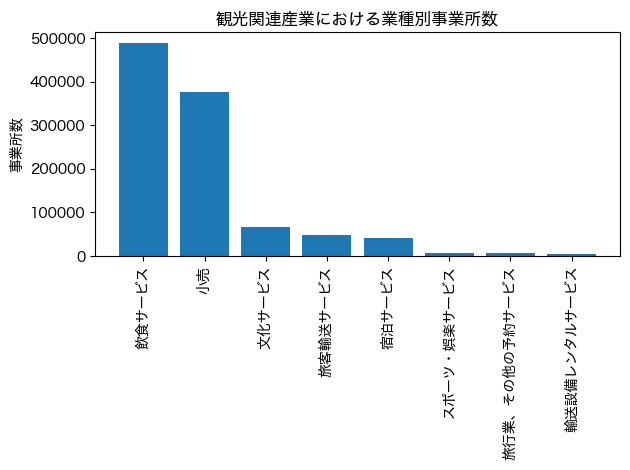

In [29]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Hiragino Sans"


plt.figure()
plt.bar(result["業種"], result["総数"])
plt.xticks(rotation=90)
plt.ylabel("事業所数")
plt.title("観光関連産業における業種別事業所数")
plt.tight_layout()
plt.show()
